In [8]:
import os
import torch
import warnings

warnings.filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

print("Torch Version:", torch.__version__)
print("CUDA Availablility:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Torch Version: 2.5.1+cu121
CUDA Availablility: True
GPU Name: NVIDIA RTX 2000 Ada Generation Laptop GPU
Device: cuda


In [3]:
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
from matplotlib import pyplot as plt
from PIL import Image

def show_images(x):
    """Given a batch of images x, make a grid and convert to PIL"""
    x = x * 0.5 + 0.5   # map from (-1, 1) back to (0, 1)
    grid = torchvision.utils.make_grid(x)
    grid_im = grid.detach().cpu().permute(1, 2, 0).clip(0, 1) * 255
    grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))
    return grid_im

def make_grid(images, size=64):
    """Given a list of PIL images, stack them together into a line for easy viewing"""
    output_im = Image.new("RGB", (size * len(images), size))
    for i, im in enumerate(images):
        output_im.paste(im.resize((size, size)), (i * size, 0))
    return output_im

Resizing the entire dataset to 64x64...
Resizing complete!
Caption: a drawing of a green pokemon with red eyes
Image Object: <PIL.PngImagePlugin.PngImageFile image mode=RGB size=64x64 at 0x17A80AC6A10>


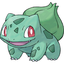

In [4]:
import torchvision
from datasets import load_dataset
from torchvision import transforms
from PIL import Image
from IPython.display import display

# 0. Load the dataset from Hugging Face
dataset = load_dataset("reach-vb/pokemon-blip-captions", split="train")

# 1. Define a function to resize the whole dataset
def resize_images(batch):
    # Resize every image in the current batch to 64x64 using Lanczos resampling
    batch["image"] = [img.resize((64, 64), Image.Resampling.LANCZOS) for img in batch["image"]]
    return batch

print("Resizing the entire dataset to 64x64...")
dataset = dataset.map(resize_images, batched=True)   # .map(batched=True) processes the dataset quickly in batches
print("Resizing complete!")

# 2. Access a single sample (e.g., the first item)
sample = dataset[0]

# 3. Print the text caption and the image details
print(f"Caption: {sample['text']}")
print(f"Image Object: {sample['image']}")   # This will now show size=(64, 64)

# 4. Display the image
display(sample['image'])

In [5]:
image_size = 64
batch_size = 32

# Define data augmentations
preprocess = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),    # Resize
        transforms.RandomHorizontalFlip(),              # Randomly flip for data augmentations
        transforms.ToTensor(),                          # Convert to tensor (0, 1) and swap the axes to (C, H, W)
        transforms.Normalize([0.5], [0.5]),             # Map to (-1, 1): zero-centered data, which helps optimization algorithms (like gradient descent) converge much faster
    ]
)

def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}

dataset.set_transform(transform)

Sample shape: torch.Size([8, 3, 64, 64])


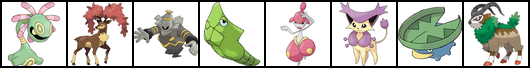

In [6]:
# Create a dataloader from the dataset to serve up the transformed images in batches
train_dataloader = torch.utils.data.DataLoader(
    dataset=dataset, 
    batch_size=batch_size, 
    shuffle=True
)

sample = next(iter(train_dataloader))["images"].to(device)[:8]
print("Sample shape:", sample.shape)    # (8, C=3, H=64, W=64)

show_images(sample)

Noisy sample shape: torch.Size([8, 3, 64, 64])


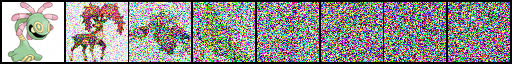

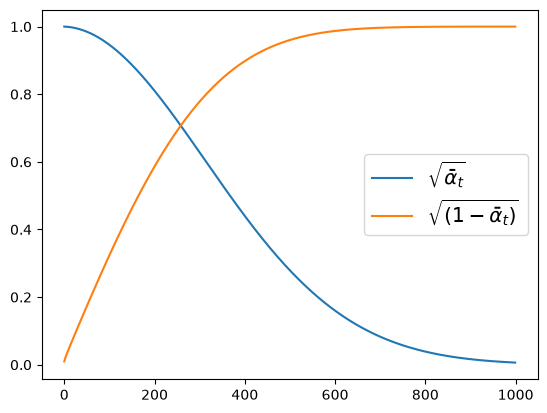

In [9]:
# Define the Scheduler: The noise schedule determines how much noise is added at different timesteps.
from diffusers import DDPMScheduler     # Denoising Diffusion Probabilistic Models (DDPM)

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$")
plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{(1 - \bar{\alpha}_t)}$")
plt.legend(fontsize="x-large");

timesteps = torch.linspace(0, 999, 8).long().to(device)
noise = torch.randn_like(sample)
noisy_sample = noise_scheduler.add_noise(sample, noise, timesteps)

print("Noisy sample shape:", noisy_sample.shape)
show_images(noisy_sample).resize((8 * 64, 64), resample=Image.NEAREST)

In [12]:
# Define the Model
from diffusers import UNet2DModel

model = UNet2DModel(
    sample_size=image_size,                 # the target image resolution
    in_channels=3,                          # the number of input channels, 3 for RGB images
    out_channels=3,                         # the number of output channels
    layers_per_block=2,                     # how many ResNet layers to use per UNet block
    block_out_channels=(64, 128, 128, 256), # More channels -> more parameters
    down_block_types=(
        "DownBlock2D",                      # Level 1: a regular ResNet downsampling block, output: 64 channels
        "DownBlock2D",                      # Level 2: 128 channels
        "AttnDownBlock2D",                  # Level 3: a ResNet downsampling block with spatial self-attention, output: 128 channels
        "AttnDownBlock2D",                  # Level 4: 256 channels (with spatial self-attention)
    ),
    up_block_types=(
        "AttnUpBlock2D",                    # Level 4: a ResNet upsampling block with spatial self-attention, output: 128 channels
        "AttnUpBlock2D",                    # Level 3: 128 channels (with spatial self-attention)
        "UpBlock2D",                        # Level 2: a regular ResNet upsampling block, output: 64 channels
        "UpBlock2D",                        # Level 1: outputs 64 channels (final conv layer will then reduce this to out_channels=3)
    ),
)

model.to(device)

UNet2DModel(
  (conv_in): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=64, out_features=256, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=256, out_features=256, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 64, eps=1e-05, affine=True)
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=256, out_features=64, bias=True)
          (norm2): GroupNorm(32, 64, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(64, 64, ker

In [ ]:
"""
    DownBlock2D is best used for:
        - High-resolution levels (the early stages of the U-Net).
        - Capturing local, neighboring features like edges, textures, and simple shapes.
        - Keeping computational complexity and memory usage low.
    
    AttnDownBlock2D = ResnetBlock2D + AttentionBlock (Self-Attention) + Downsampler2D
        The AttentionBlock (Self-Attention) allows every pixel in the feature map to look at and interact with every other pixel, 
        regardless of how far apart they are in the image.
"""

In [ ]:
# Training Loop
